In [1]:
# Import libraries
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np

## 1. Initialize H2O

In [2]:
?H2OAutoML

Init signature:
H2OAutoML(
    nfolds=-1,
    balance_classes=False,
    class_sampling_factors=None,
    max_after_balance_size=5.0,
    max_runtime_secs=None,
    max_runtime_secs_per_model=None,
    max_models=None,
    distribution='AUTO',
    stopping_metric='AUTO',
    stopping_tolerance=None,
    stopping_rounds=3,
    seed=None,
    project_name=None,
    exclude_algos=None,
    include_algos=None,
    exploitation_ratio=-1,
    modeling_plan=None,
    preprocessing=None,
    monotone_constraints=None,
    keep_cross_validation_predictions=False,
    keep_cross_validation_models=False,
    keep_cross_validation_fold_assignment=False,
    sort_metric='AUTO',
    custom_metric_func=None,
    export_checkpoints_dir=None,
    verbosity='warn',
    **kwargs,
)
Docstring:     
Automatic Machine Learning

The Automatic Machine Learning (AutoML) function automates the supervised machine learning model training process.
It trains several models, cross-validated by default, by using the 

In [2]:
# Start H2O cluster
print("="*80)
print("Initializing H2O cluster...")
print("="*80)

h2o.init(
    max_mem_size='4G',  # Maximum memory
    nthreads=-1  # Use all available threads
)

print(f"\nH2O cluster info:")
print(h2o.cluster().show_status())

# Access H2O Flow UI at http://localhost:54321
print("\nAccess H2O Flow UI at: http://localhost:54321")

Initializing H2O cluster...
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.1" 2025-10-21; OpenJDK Runtime Environment Homebrew (build 25.0.1); OpenJDK 64-Bit Server VM Homebrew (build 25.0.1, mixed mode, sharing)
  Starting server from /Users/tarekatwan/Repos/MyWork/Teach/Ensemble Methods/Creo/demos/AutoML/dev1/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/48/j6k669vx63qd_68k2_502cl40000gn/T/tmpj6hpnm7w
  JVM stdout: /var/folders/48/j6k669vx63qd_68k2_502cl40000gn/T/tmpj6hpnm7w/h2o_tarekatwan_started_from_python.out
  JVM stderr: /var/folders/48/j6k669vx63qd_68k2_502cl40000gn/T/tmpj6hpnm7w/h2o_tarekatwan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Asia/Amman
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_tarekatwan_0rncwp
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.981 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"



H2O cluster info:


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Asia/Amman
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_tarekatwan_0rncwp
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.981 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"


None

Access H2O Flow UI at: http://localhost:54321


## 2. Load Data

In [3]:
# Import data into H2O
print("\n" + "="*80)
print("Loading data...")
print("="*80)

# Load sample dataset (using H2O's built-in dataset)
df = h2o.import_file("https://s3.amazonaws.com/h2o-public-test-data/smalldata/prostate/prostate.csv")

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Identify features and target
y = "CAPSULE"
x = df.columns
x.remove(y)
x.remove("ID")  # Remove ID column

print(f"\nTarget: {y}")
print(f"Features: {x}")

# Convert target to factor for classification
df[y] = df[y].asfactor()


Loading data...
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Dataset shape: (380, 9)

First 5 rows:
  ID    CAPSULE    AGE    RACE    DPROS    DCAPS    PSA    VOL    GLEASON
   1          0     65       1        2        1    1.4    0            6
   2          0     72       1        3        2    6.7    0            7
   3          0     70       1        1        2    4.9    0            6
   4          0     76       2        2        1   51.2   20            7
   5          0     69       1        1        1   12.3   55.9          6
   6          1     71       1        3        2    3.3    0            8
   7          0     68       2        4        2   31.9    0            7
   8          0     61       2        4        2   66.7   27.2          7
   9          0     69       1        1        1    3.9   24            7
  10          0     68       2        1        2   13      0            6
[10 rows x 9 columns]


Target: CAP

## 3. Split Data

In [4]:
# Split into train, validation, and test sets
print("\n" + "="*80)
print("Splitting data...")
print("="*80)

train, valid, test = df.split_frame(ratios=[0.7, 0.15], seed=42)

print(f"Train set: {train.shape}")
print(f"Validation set: {valid.shape}")
print(f"Test set: {test.shape}")


Splitting data...
Train set: (265, 9)
Validation set: (59, 9)
Test set: (56, 9)


## 4. Basic AutoML Training

In [5]:
# Run AutoML with default settings
print("\n" + "="*80)
print("Training H2O AutoML (Basic)...")
print("="*80)

aml = H2OAutoML(
    max_runtime_secs=120,  # Maximum runtime in seconds
    max_models=20,  # Maximum number of models
    seed=42,
    project_name='prostate_basic',
    stopping_metric='AUC',
    sort_metric='AUC',
    nfolds=5  # Cross-validation folds
)

aml.train(
    x=x,
    y=y,
    training_frame=train,
    validation_frame=valid
)

print("\nAutoML training complete!")


Training H2O AutoML (Basic)...
AutoML progress: |
14:52:12.152: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
14:52:12.158: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%

AutoML training complete!


## 5. View Leaderboard

In [7]:
# View model leaderboard
print("\n" + "="*80)
print("AutoML Leaderboard:")
print("="*80)

lb = aml.leaderboard
print(lb.head(rows=lb.nrows))


AutoML Leaderboard:
model_id                                                   auc    logloss     aucpr    mean_per_class_error      rmse       mse
DeepLearning_grid_1_AutoML_1_20251114_145212_model_2  0.821642   0.539875  0.766583                0.218035  0.417107  0.173979
DeepLearning_grid_2_AutoML_1_20251114_145212_model_1  0.816188   0.604759  0.712145                0.239883  0.434401  0.188704
DRF_1_AutoML_1_20251114_145212                        0.813959   0.896804  0.672312                0.221261  0.416571  0.173532
GLM_1_AutoML_1_20251114_145212                        0.812845   0.514164  0.751916                0.256012  0.415784  0.172877
GBM_grid_1_AutoML_1_20251114_145212_model_5           0.803519   0.538991  0.707577                0.250733  0.422809  0.178767
GBM_4_AutoML_1_20251114_145212                        0.802111   0.539062  0.69077                 0.215396  0.422703  0.178677
GBM_grid_1_AutoML_1_20251114_145212_model_4           0.800587   0.544969  0.700551

## 6. Best Model

In [8]:
# Access the best model
print("\n" + "="*80)
print("Best Model Information:")
print("="*80)

leader = aml.leader
print(f"\nBest model ID: {leader.model_id}")
print(f"Model type: {leader.algo}")

# Model performance
perf = leader.model_performance(test)
print(f"\nTest AUC: {perf.auc()}")
print(f"Test Accuracy: {perf.accuracy()}")
print(f"Test Logloss: {perf.logloss()}")


Best Model Information:

Best model ID: DeepLearning_grid_1_AutoML_1_20251114_145212_model_2
Model type: deeplearning

Test AUC: 0.7694334650856389
Test Accuracy: [[0.7191389666040493, 0.75]]
Test Logloss: 0.7023404866278878


## 7. Predictions

In [9]:
# Make predictions
print("\n" + "="*80)
print("Making predictions...")
print("="*80)

predictions = leader.predict(test)
print("\nPredictions (first 10 rows):")
print(predictions.head(10))


Making predictions...
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%

Predictions (first 10 rows):
  predict           p0          p1
        0  0.940799     0.0592011
        0  0.993083     0.00691716
        1  0.101213     0.898787
        0  0.927993     0.0720071
        1  0.780861     0.219139
        1  0.0137969    0.986203
        1  5.44007e-06  0.999995
        0  0.989638     0.0103621
        1  0.0974367    0.902563
        0  0.972246     0.0277536
[10 rows x 3 columns]



## 8. Model Metrics

In [10]:
# Detailed performance metrics
print("\n" + "="*80)
print("Detailed Performance Metrics:")
print("="*80)

print("\nConfusion Matrix:")
print(perf.confusion_matrix())

print("\nMetrics:")
print(f"Precision: {perf.precision()}")
print(f"Recall: {perf.recall()}")
print(f"F1 Score: {perf.F1()}")


Detailed Performance Metrics:

Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.19966292973999453
       0    1    Error    Rate
-----  ---  ---  -------  -----------
0      28   5    0.1515   (5.0/33.0)
1      7    16   0.3043   (7.0/23.0)
Total  35   21   0.2143   (12.0/56.0)

Metrics:
Precision: [[0.9999999999983589, 1.0]]
Recall: [[1.925731418860838e-05, 1.0]]
F1 Score: [[0.19966292973999453, 0.7272727272727272]]


## 9. Variable Importance

In [10]:
# Feature importance
print("\n" + "="*80)
print("Variable Importance:")
print("="*80)

varimp = leader.varimp(use_pandas=True)
print(varimp)


Variable Importance:
  variable  relative_importance  scaled_importance  percentage
0      PSA             1.000000           1.000000    0.201556
1    DCAPS             0.756767           0.756767    0.152531
2    DPROS             0.749798           0.749798    0.151126
3  GLEASON             0.686248           0.686248    0.138318
4      VOL             0.626671           0.626671    0.126309
5     RACE             0.572608           0.572608    0.115413
6      AGE             0.569302           0.569302    0.114746


## 10. Model Explainability

In [11]:
# Generate explanations
print("\n" + "="*80)
print("Model Explainability...")
print("="*80)

# Generate model explanations
explanation = leader.explain(test, render=False)
print("Model explanation generated!")


Model Explainability...
Model explanation generated!


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_1_AutoML_1_20251114_145212_model_2

,0,1,Error,Rate
0,14.0,19.0,0.5758,(19.0/33.0)
1,1.0,22.0,0.0435,(1.0/23.0)
Total,15.0,41.0,0.3571,(20.0/56.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

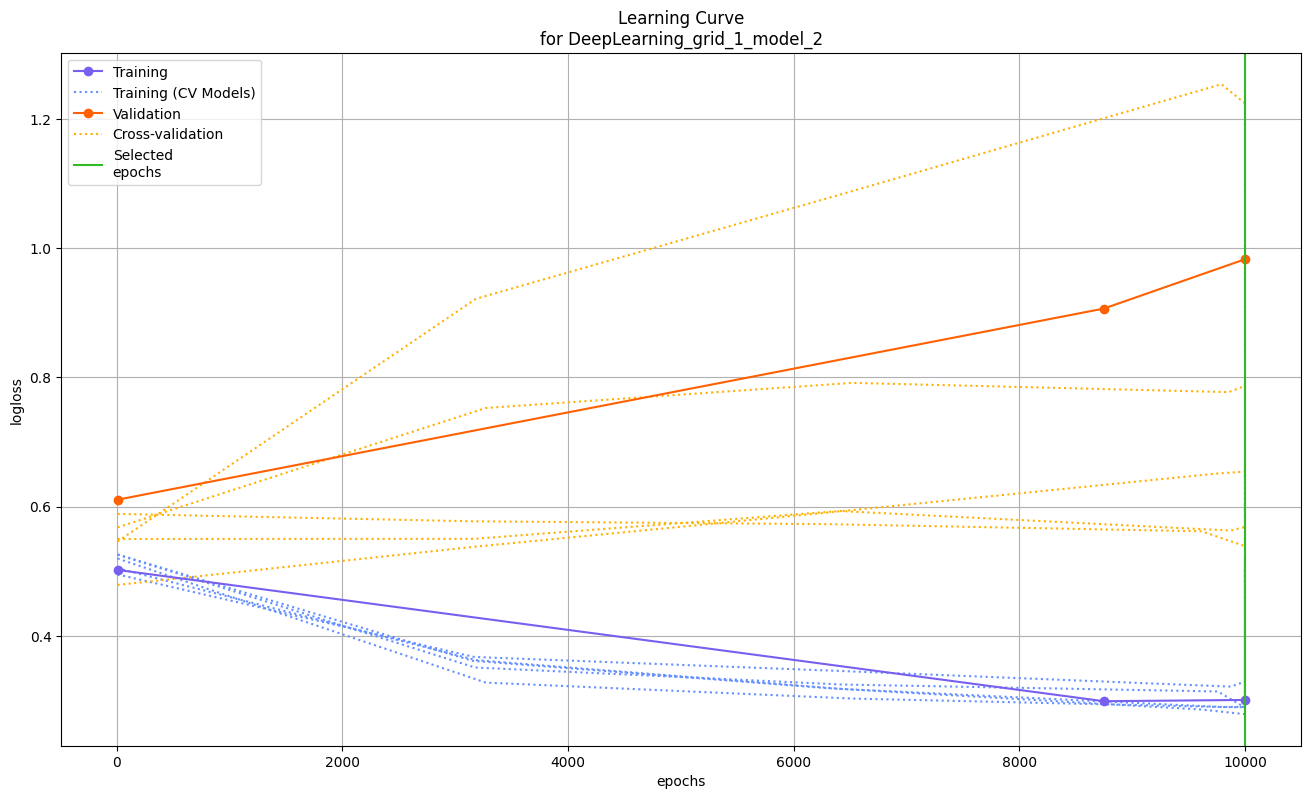

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

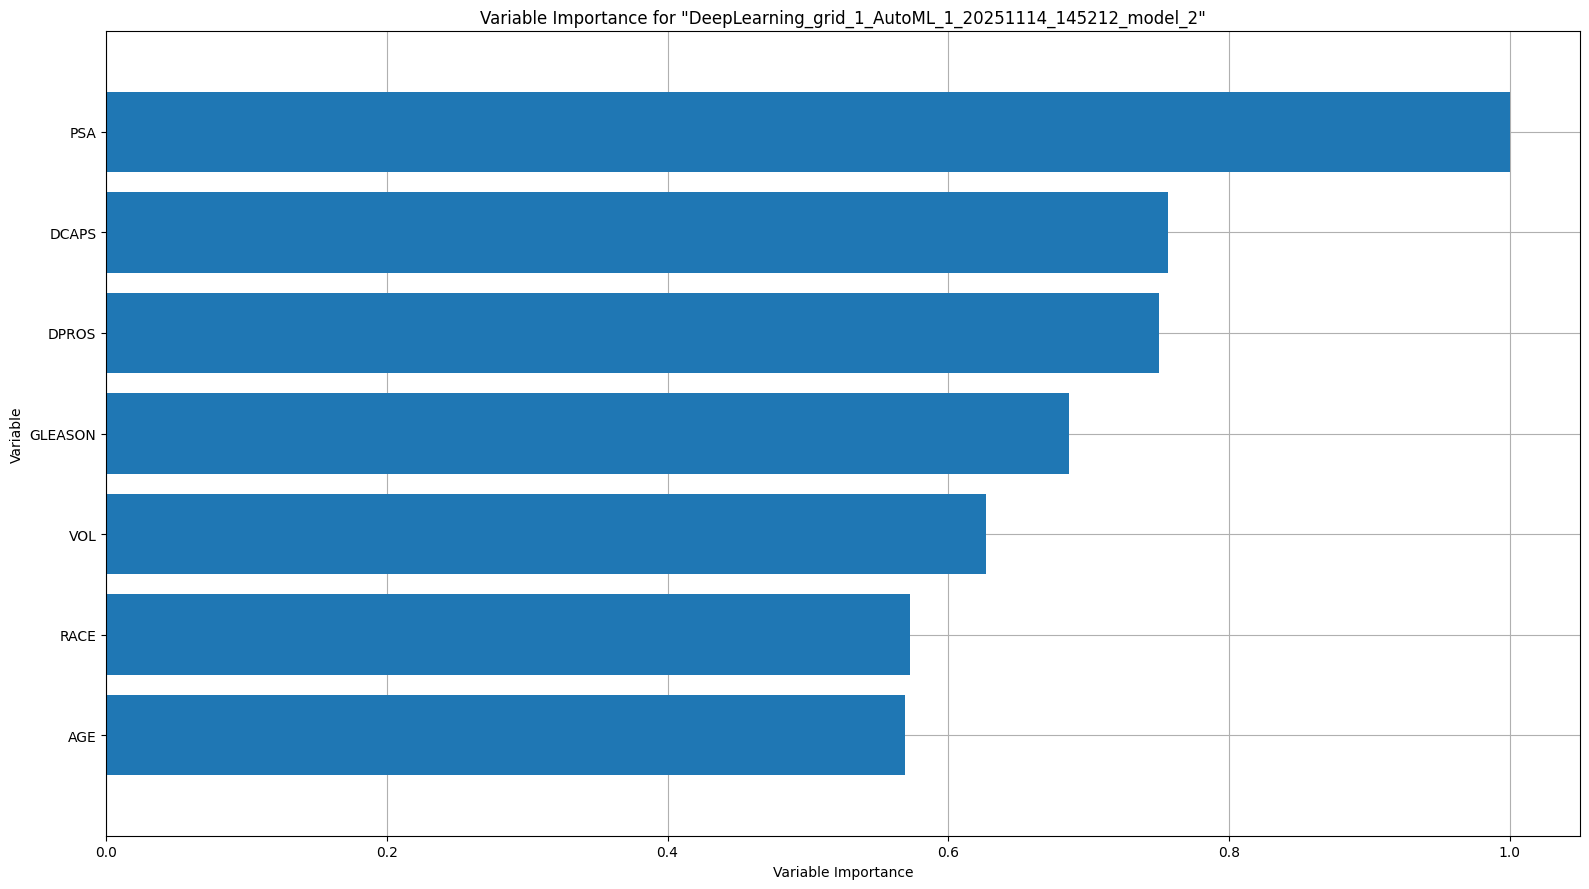

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

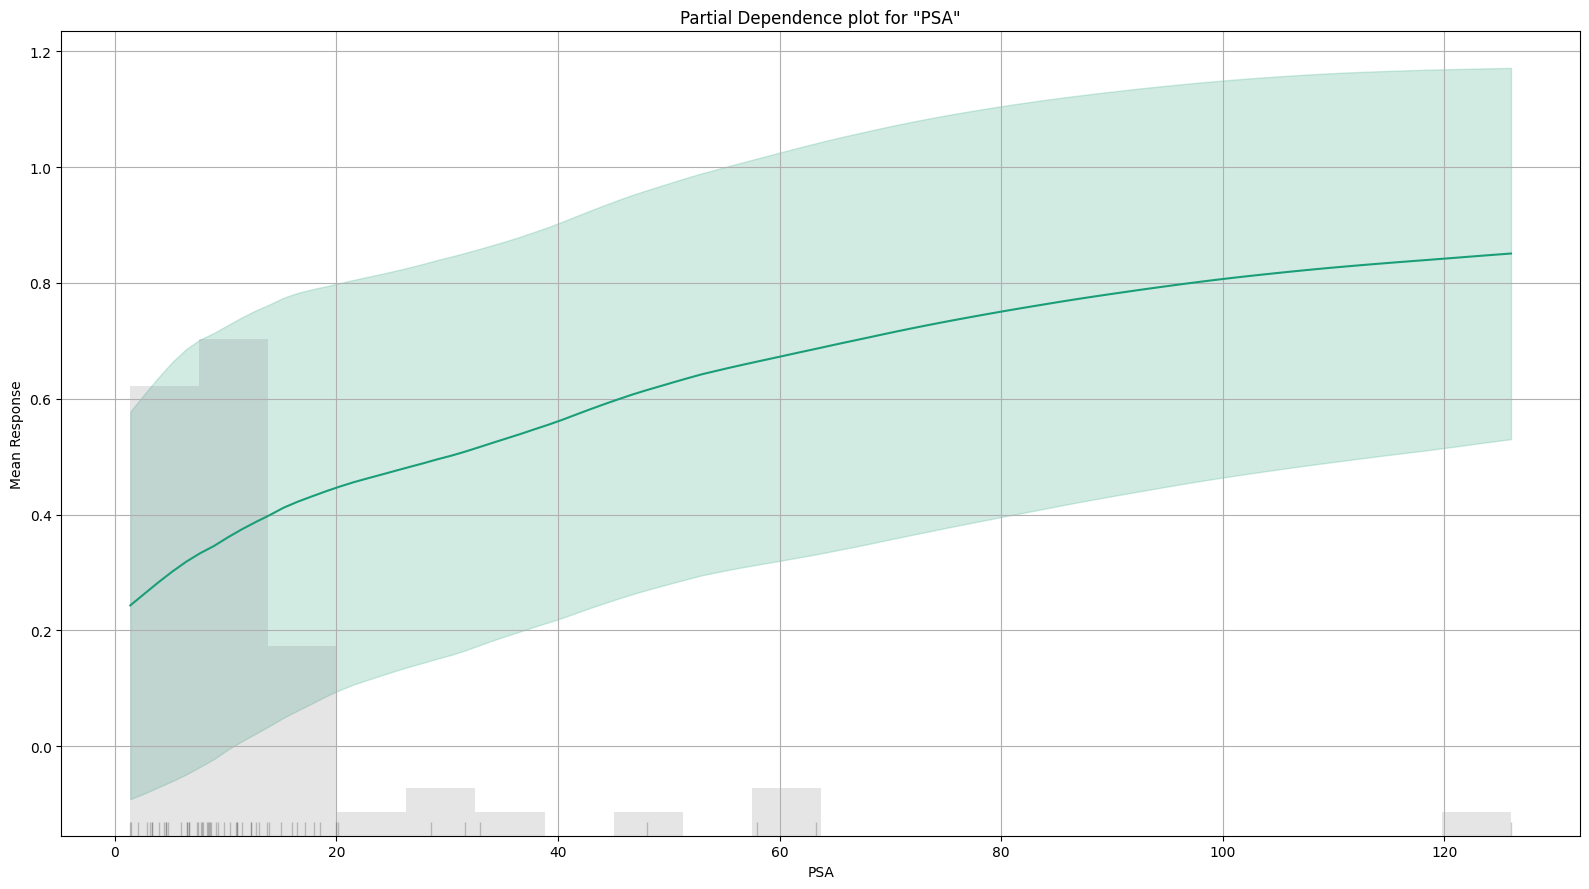

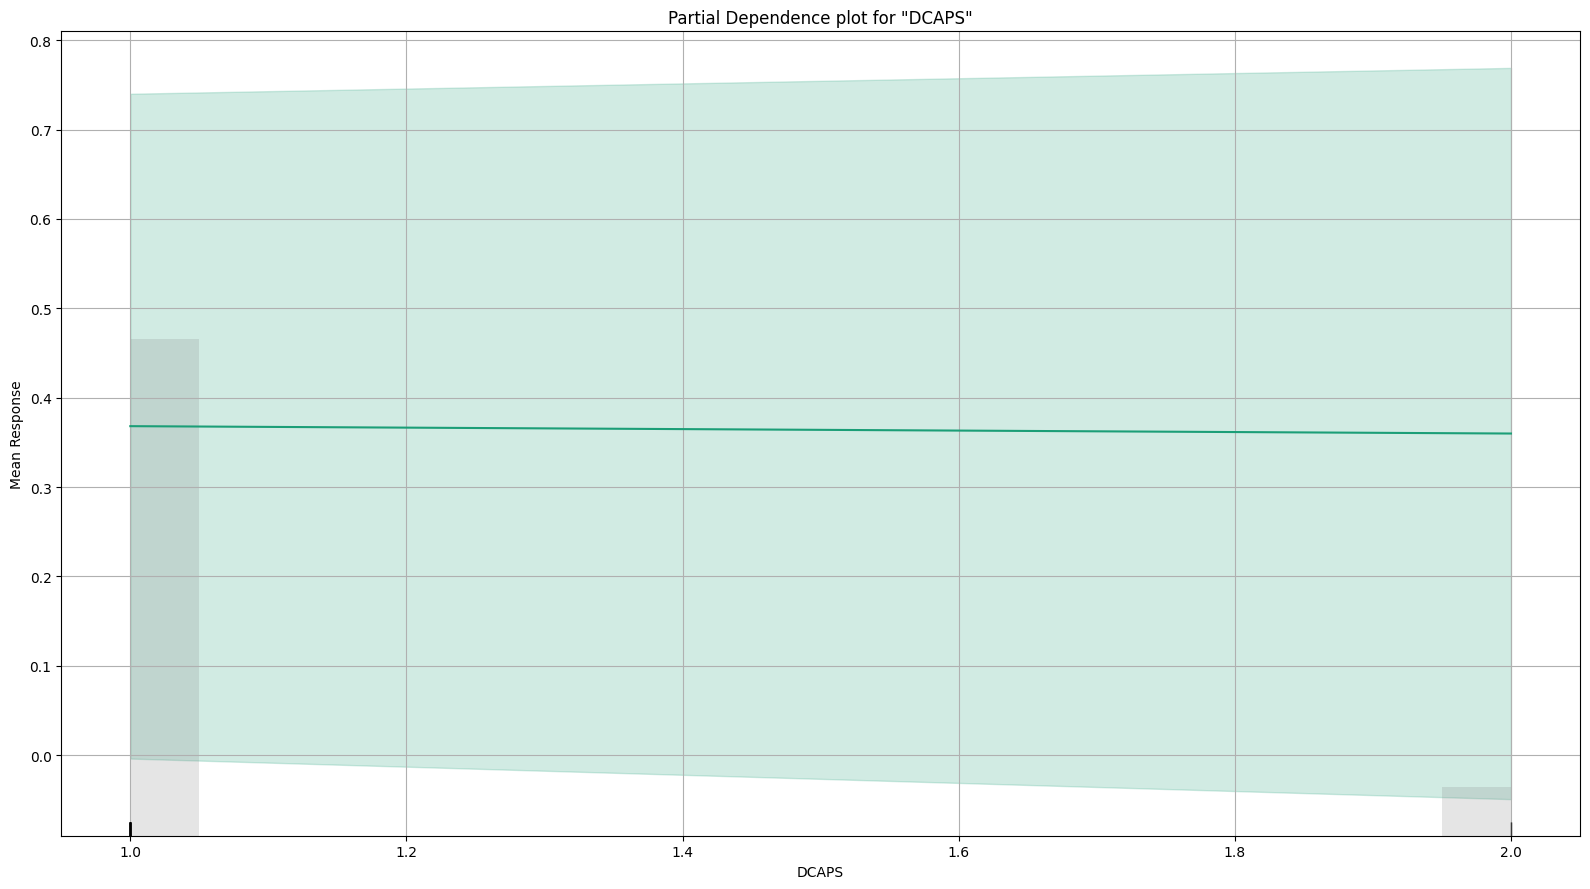

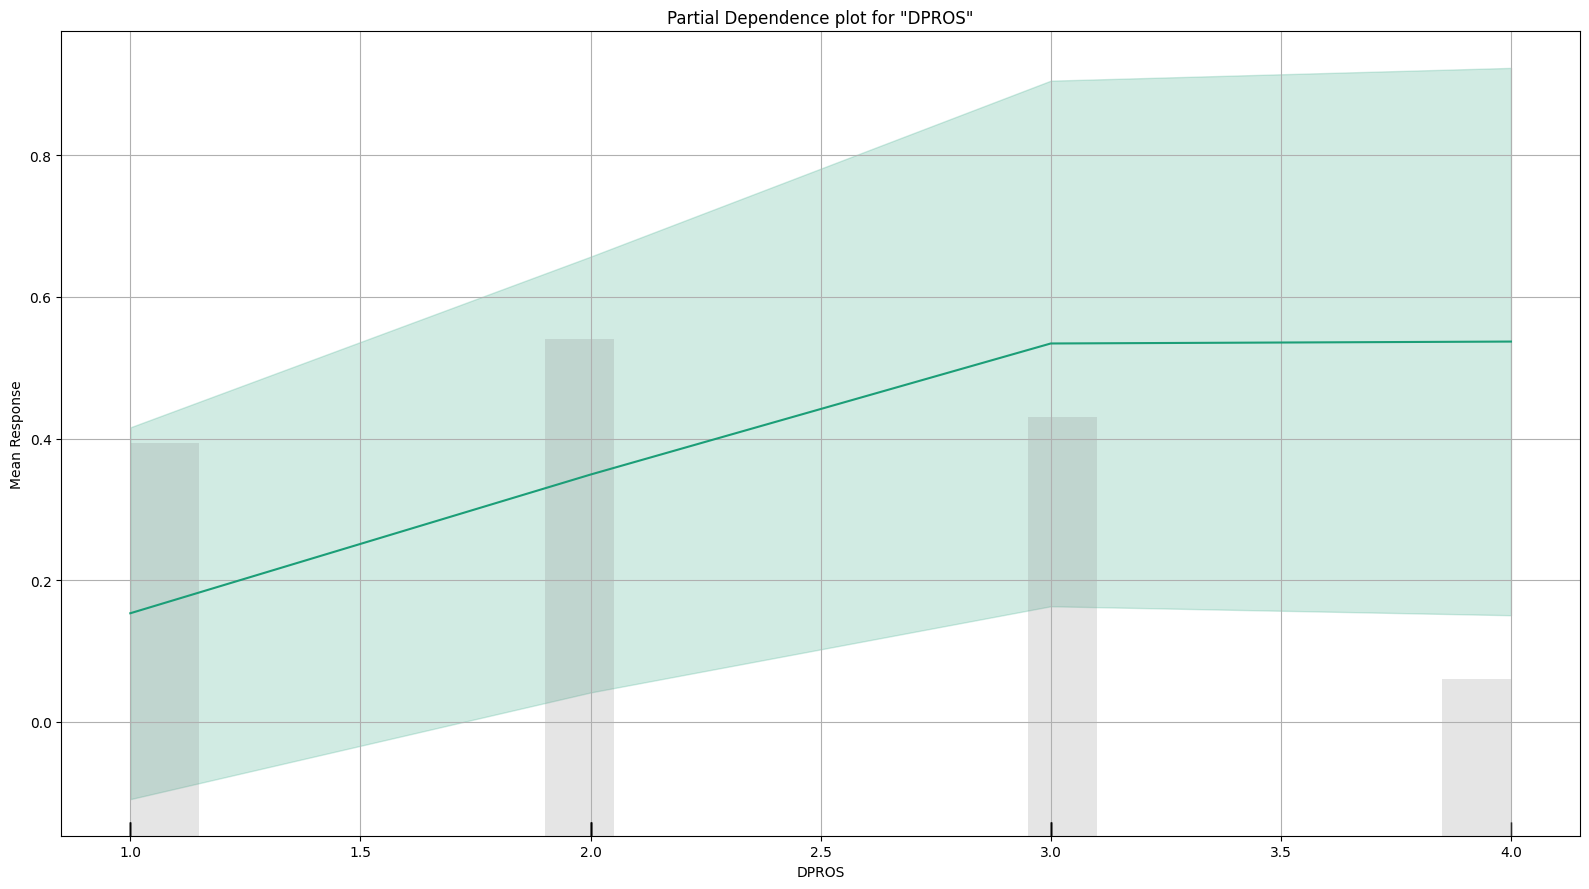

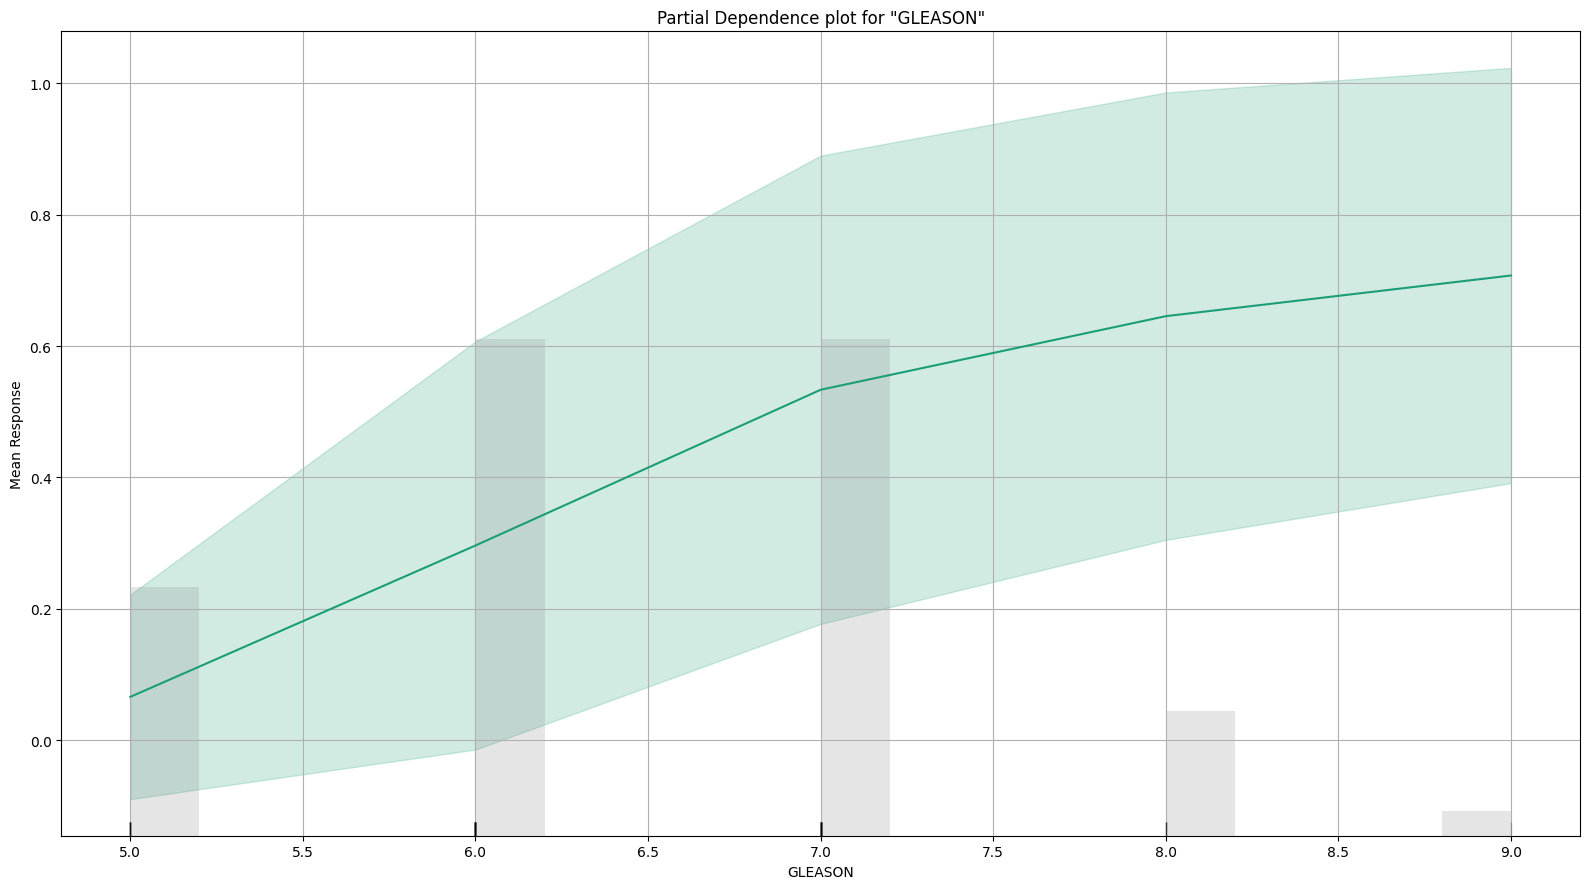

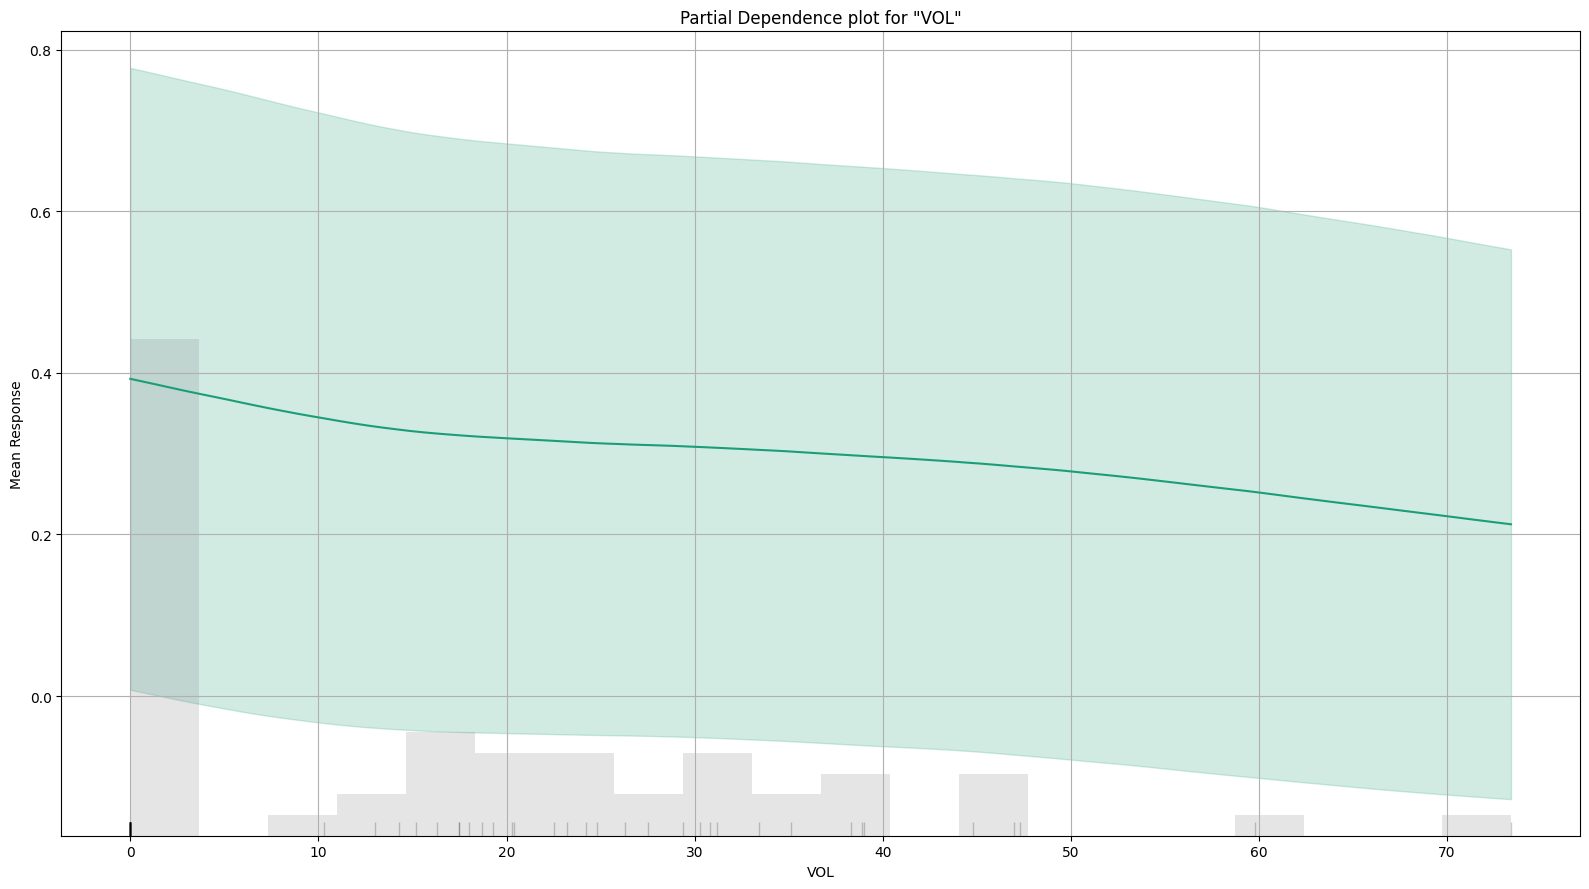

In [12]:
explanation

## 11. Advanced AutoML

In [15]:
# Train with advanced configurations
print("\n" + "="*80)
print("Training H2O AutoML (Advanced)...")
print("="*80)

aml_advanced = H2OAutoML(
    max_runtime_secs=180,
    max_models=30,
    seed=42,
    project_name='prostate_advanced',
    stopping_metric='AUC',
    sort_metric='AUC',
    nfolds=5,
    balance_classes=True,  # Balance classes for imbalanced data
    class_sampling_factors=[1.0, 1.5],  # Custom sampling factors
    max_after_balance_size=3.0,
    keep_cross_validation_predictions=True,
    keep_cross_validation_models=True,
    keep_cross_validation_fold_assignment=True,
    include_algos=['GBM', 'XGBoost', 'DRF', 'GLM', 'DeepLearning'],  # Specific algorithms
    exclude_algos=None,
    exploitation_ratio=0.1,  # Exploration vs exploitation balance
    monotone_constraints=None,
    export_checkpoints_dir=None
)

aml_advanced.train(
    x=x,
    y=y,
    training_frame=train,
    validation_frame=valid,
    leaderboard_frame=test
)

print("\nAdvanced AutoML training complete!")
print(f"\nTotal models trained: {aml_advanced.leaderboard.nrows}")


Training H2O AutoML (Advanced)...
AutoML progress: |


13:36:05.488: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
13:36:05.488: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%

Advanced AutoML training complete!

Total models trained: 25


## 12. Ensemble Models

In [16]:
# Access stacked ensemble models
print("\n" + "="*80)
print("Stacked Ensemble Models:")
print("="*80)

# Get all stacked ensemble models
se_models = [m for m in aml_advanced.leaderboard['model_id'].as_data_frame()['model_id'] 
             if 'StackedEnsemble' in m]
print(f"\nNumber of stacked ensembles: {len(se_models)}")
print("Ensemble models:")
for se in se_models:
    print(f"  - {se}")


Stacked Ensemble Models:

Number of stacked ensembles: 0
Ensemble models:


/Users/tarekatwan/Repos/MyWork/Teach/Ensemble Methods/Creo/demos/AutoML/dev1/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## 13. Model Comparison

In [17]:
# Compare specific models
print("\n" + "="*80)
print("Model Comparison:")
print("="*80)

# Get top 5 models
top_5_ids = aml_advanced.leaderboard['model_id'].as_data_frame()['model_id'][:5].tolist()

comparison_data = []
for model_id in top_5_ids:
    model = h2o.get_model(model_id)
    perf = model.model_performance(test)
    comparison_data.append({
        'Model': model_id,
        'AUC': perf.auc(),
        'Accuracy': perf.accuracy()[0][1],
        'Logloss': perf.logloss()
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Model Comparison:
                                               Model      AUC  Accuracy  Logloss
             DeepLearning_1_AutoML_2_20251114_133605 0.818182  0.767857 0.526914
                      GLM_1_AutoML_2_20251114_133605 0.805007  0.767857 0.533349
                      GBM_3_AutoML_2_20251114_133605 0.799736  0.767857 0.537016
DeepLearning_grid_1_AutoML_2_20251114_133605_model_4 0.797101  0.821429 1.021884
         GBM_grid_1_AutoML_2_20251114_133605_model_5 0.787879  0.767857 0.564297


/Users/tarekatwan/Repos/MyWork/Teach/Ensemble Methods/Creo/demos/AutoML/dev1/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## 14. Save Model

In [14]:
# Save model for deployment
print("\n" + "="*80)
print("Saving model...")
print("="*80)

model_path = h2o.save_model(model=leader, path="./h2o_models", force=True)
print(f"Model saved to: {model_path}")


Saving model...
Model saved to: /Users/tarekatwan/Repos/MyWork/Teach/Ensemble Methods/Creo/demos/AutoML/AutoML_Patch_3/h2o_models/DeepLearning_grid_1_AutoML_1_20251114_145212_model_2


## 15. Load Model

In [15]:
# Load saved model
print("\n" + "="*80)
print("Loading model...")
print("="*80)

loaded_model = h2o.load_model(model_path)
print(f"Model loaded: {loaded_model.model_id}")

# Verify predictions match
loaded_predictions = loaded_model.predict(test)
print("\nPredictions from loaded model (first 5):")
print(loaded_predictions.head())


Loading model...
Model loaded: DeepLearning_grid_1_AutoML_1_20251114_145212_model_2
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%

Predictions from loaded model (first 5):
  predict           p0          p1
        0  0.940799     0.0592011
        0  0.993083     0.00691716
        1  0.101213     0.898787
        0  0.927993     0.0720071
        1  0.780861     0.219139
        1  0.0137969    0.986203
        1  5.44007e-06  0.999995
        0  0.989638     0.0103621
        1  0.0974367    0.902563
        0  0.972246     0.0277536
[10 rows x 3 columns]



## 16. Export to MOJO/POJO

In [20]:
# Export for production deployment
print("\n" + "="*80)
print("Exporting model for production...")
print("="*80)

# Export as MOJO (Model Object, Optimized)
mojo_path = leader.download_mojo(path="./h2o_models", get_genmodel_jar=True)
print(f"MOJO exported to: {mojo_path}")

# Export as POJO (Plain Old Java Object)
# pojo_path = leader.download_pojo(path="./h2o_models")
# print(f"POJO exported to: {pojo_path}")


Exporting model for production...
MOJO exported to: /Users/tarekatwan/Repos/MyWork/Teach/Ensemble Methods/Creo/demos/AutoML/AutoML_Patch_1/notebooks/h2o_models/DeepLearning_grid_2_AutoML_1_20251114_133200_model_1.zip


## 17. Grid Search (Manual)

In [ ]:
# Manual grid search for specific algorithm
print("\n" + "="*80)
print("Manual Grid Search...")
print("="*80)

from h2o.grid.grid_search import H2OGridSearch
from h2o.estimators import H2OGradientBoostingEstimator

# Define hyperparameters for grid search
gbm_params = {
    'max_depth': [3, 5, 7],
    'ntrees': [50, 100, 150],
    'learn_rate': [0.01, 0.1, 0.2]
}

# Create GBM model
gbm = H2OGradientBoostingEstimator(
    nfolds=5,
    seed=42,
    stopping_rounds=3,
    stopping_metric="AUC"
)

# Perform grid search
grid = H2OGridSearch(
    model=gbm,
    hyper_params=gbm_params,
    search_criteria={
        'strategy': 'RandomDiscrete',
        'max_models': 10,
        'seed': 42
    }
)

grid.train(
    x=x,
    y=y,
    training_frame=train,
    validation_frame=valid
)

print(f"\nGrid search complete! Trained {len(grid.model_ids)} models")
print("\nGrid Search Results:")
print(grid.get_grid(sort_by='auc', decreasing=True))

## 18. Shutdown H2O

In [17]:
# Demo completion
print("\n" + "="*80)
print("H2O AutoML Demo Complete!")
print("="*80)
print("\nKey Takeaways:")
print("- Distributed and scalable architecture")
print("- Automatic model stacking and ensembling")
print("- Multiple algorithm support (GBM, XGBoost, DL, GLM, RF)")
print("- Built-in cross-validation")
print("- Model explainability and interpretability")
print("- Production-ready exports (MOJO/POJO)")
print("- Web UI for monitoring (H2O Flow)")
print("- Enterprise-grade performance")

# Shutdown H2O cluster (optional)
h2o.cluster().shutdown()


H2O AutoML Demo Complete!

Key Takeaways:
- Distributed and scalable architecture
- Automatic model stacking and ensembling
- Multiple algorithm support (GBM, XGBoost, DL, GLM, RF)
- Built-in cross-validation
- Model explainability and interpretability
- Production-ready exports (MOJO/POJO)
- Web UI for monitoring (H2O Flow)
- Enterprise-grade performance
H2O session _sid_a0fc closed.
